In [22]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import time
from IPython.display import display

# 1 : Backtracking vs. Wolfe
## 1.1 : Chargement des données

Implémentez une fonction `def load_data(name):` qui prend en entrée un nom de fichier `.mat` et retourne :
- `classe1` : l’ensemble des données `a^(i)` de la classe 1 (`y^(i)=1`),
- `classe2` : l’ensemble des données `a^(i)` de la classe 2 (`y^(i)=0`).

In [23]:
def load_data(name):
    mat_data = scipy.io.loadmat("dataNeurone/"+name)
    a = mat_data['a']  # Matrice des points
    y = mat_data['y']  # Labels des classes

    # Conversion en matrice dense si nécessaire
    if isinstance(a, scipy.sparse.csc_matrix):
        a = a.toarray()

    # Identifier les classes
    id1 = np.where(y == 1)[0]
    id2 = np.where(y == 0)[0]

    # Retourner les sous-ensembles
    return a[id1, :], a[id2, :]

## 1.2 : Fonction d'optimisation

Implémentez une fonction 

`def optimisation(classe1, classe2, methode="grad", pas="wolfe", maxiter=10**4, maxtime=10):`

dont les sorties sont :
- `x` : les valeurs finales attribuées aux variables,
- `f` : l'ensemble des valeurs de la fonction objectif aux différents itérés,
- `t` : l’ensemble des instants auxquels la fonction objectif a été évaluée.

Cette fonction définira en son sein les différentes focntions nécessaires :
- `def fln(x):` pour évaluer `f` et son gradient `g`.
- Les fonctions pour les conditions de Wolfe (`w1`, `w2`, `wolfebissection`) si `pas="wolfe"`.
- Une fonction `backtrackingsimple` si `pas="backtracking"`.
- Les méthodes `methgradient` et `methgradientACC` selon `methode`.

Vous utiliserez les données `classe1` et `classe 2` adaptées (ajout de la colonne de 1).

In [24]:
def optimisation(classe1, classe2, methode='grad', pas='wolfe', maxiter=10**4, maxtime=180):
    n1, m = classe1.shape
    n2, m = classe2.shape

    # On ajoute la colonne de 1 pour le biais
    a1 = np.ones((n1, m+1))
    a2 = np.ones((n2, m+1))
    a1[:, 1:] = classe1
    a2[:, 1:] = classe2

    def fln(x):
        exp1 = np.exp(-np.clip(a1 @ x, -50, 50))
        f1 = np.sum(np.log(1 + exp1))
        v1 = exp1 / (1 + exp1)

        exp2 = np.exp(np.clip(a2 @ x, -50, 50))
        f2 = np.sum(np.log(1 + exp2))
        v2 = exp2 / (1 + exp2)

        f = f1 + f2
        g = -a1.T @ v1 + a2.T @ v2
        return f, g

    def w1(fct, x, d, alpha, beta1=1e-4):
        f1, g1 = fct(x + alpha*d)
        f0, g0 = fct(x)
        return f1 <= f0 + beta1*alpha*(d @ g0) + 1e-9

    def w2(fct, x, d, alpha, beta2=0.9):
        f1, g1 = fct(x + alpha*d)
        f0, g0 = fct(x)
        return (d @ g1) >= beta2*(d @ g0)

    def wolfebissection(fct, x, d, alpha0=1):
        aleft = 0
        aright = np.inf
        alpha = alpha0
        while True:
            if w1(fct, x, d, alpha) and w2(fct, x, d, alpha):
                break
            if not w1(fct, x, d, alpha):
                # La condition W1 n'est pas vérifiée, le pas est trop grand
                aright = alpha
                alpha = (aleft + aright)/2
            elif not w2(fct, x, d, alpha):
                # La condition W2 n'est pas vérifiée, le pas est trop petit
                aleft = alpha
                if aright < np.inf:
                    alpha = (aleft + aright)/2
                else:
                    alpha = 2*alpha
        return alpha

    def backtrackingsimple(fct, x, d, alpha=1):
        f0, g0 = fct(x)
        f1, g1 = fct(x + alpha*d)
        while f1 > f0:
            alpha /= 2
            f1, g1 = fct(x + alpha*d)
            if alpha < 1e-16:
                break
        return alpha

    def methgradient(fct, x0, maxiter=maxiter, maxtime=maxtime):
        start_time = time.time()
        temps = np.zeros(maxiter)
        fobj = np.zeros(maxiter)
        x = x0.copy()

        for k in range(maxiter):
            f, g = fct(x)
            d = -g

            if pas == 'wolfe':
                alpha = wolfebissection(fct, x, d)
            elif pas == "backtracking":
                alpha = backtrackingsimple(fct, x, d)

            x = x + alpha*d
            f, g = fct(x)
            fobj[k] = f
            temps[k] = time.time()-start_time
            if temps[k] > maxtime:
                return x, fobj[:k+1], temps[:k+1]

        return x, fobj, temps

    def methgradientACC(fct, x0, maxiter=maxiter, maxtime=maxtime):
        start_time = time.time()
        temps = np.zeros(maxiter)
        fobj = np.zeros(maxiter)
        x = x0.copy()
        y = x0.copy()

        for k in range(maxiter):
            xprec = x.copy()
            f, g = fct(y)
            d = -g

            if pas == 'wolfe':
                alpha = wolfebissection(fct, y, d)
            elif pas == "backtracking":
                alpha = backtrackingsimple(fct, y, d)

            x = y + alpha*d
            y = x + (k/(k+3))*(x - xprec)

            f, g = fct(x)
            fobj[k] = f
            temps[k] = time.time()-start_time
            if temps[k] > maxtime:
                return x, fobj[:k+1], temps[:k+1]

        return x, fobj, temps

    x0 = np.ones(m+1)
    if methode == 'grad':
        x, f, t = methgradient(fln, x0)
    elif methode == 'gradacc':
        x, f, t = methgradientACC(fln, x0)

    return x, f, t

## 1.3 : Dérivées

Calculer les dérivées des fonctions :
$$ f_1(x) = -\ln\left(\frac{1}{1+e^{-\alpha x}}\right) = \ln(1+e^{-\alpha x}) $$
$$ f_2(x) = -\ln\left(1 - \frac{1}{1+e^{-\alpha x}}\right) = \ln(1+e^{\alpha x}) $$

----
Dérivées :
$$ f_1'(x) = \frac{d}{dx}\ln(1+e^{-\alpha x}) = -\alpha \frac{e^{-\alpha x}}{1 + e^{-\alpha x}} = -\alpha \frac{1}{1+e^{\alpha x}} $$

$$ f_2'(x) = \frac{d}{dx}\ln(1+e^{\alpha x}) = \alpha \frac{e^{\alpha x}}{1 + e^{\alpha x}} = \alpha \frac{1}{1+e^{-\alpha x}} $$

## 1.4 : Génération des figures

À l’aide des fonctions implémentées (`optimisation`), générez deux figures :

1. Pour des données de faibles dimensions :
   - Comparaison des combinaisons gradient / gradient accéléré avec calcul du pas par Wolfe / backtracking,
   - `maxtime=60`.

2. Pour des données de grandes dimensions :
   - Comparaison entre gradient et gradient accéléré avec calcul du pas par backtracking,
   - `maxtime=180`.
   
Vous utiliserez la fonction `optimisation` développée précédemment sur les jeux de données fournis.

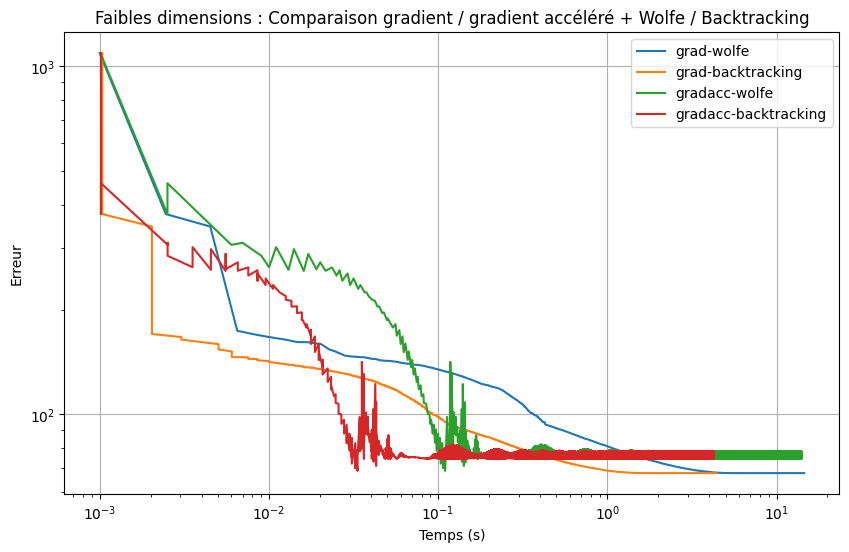

In [25]:
# Chargement des données de faibles dimensions
classe1_small, classe2_small = load_data("train_set.mat")

methods = [("grad","wolfe"), ("grad","backtracking"), ("gradacc","wolfe"), ("gradacc","backtracking")]

plt.figure(figsize=(10,6))
for methode, pas in methods:
    x, f_val, t_val = optimisation(classe1_small, classe2_small, methode=methode, pas=pas, maxiter=10**4, maxtime=60)
    plt.loglog(t_val, f_val, label=f"{methode}-{pas}")

plt.xlabel("Temps (s)")
plt.ylabel("Erreur")
plt.title("Faibles dimensions : Comparaison gradient / gradient accéléré + Wolfe / Backtracking")
plt.legend()
plt.grid(True)
plt.show()

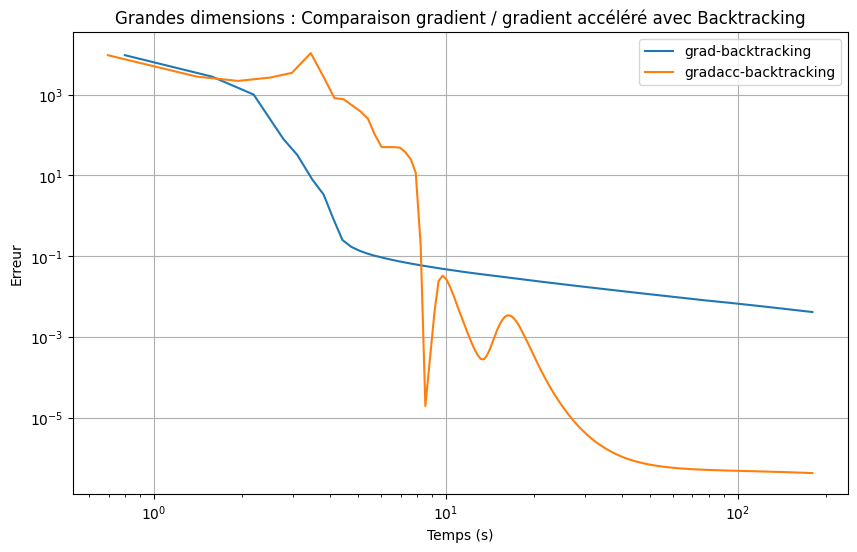

In [26]:
# Pour les données de grandes dimensions
classe1_large, classe2_large = load_data("big_train_set.mat")
methods_large = [("grad","backtracking"), ("gradacc","backtracking")]

plt.figure(figsize=(10,6))
for methode, pas in methods_large:
    x, f_val, t_val = optimisation(classe1_large, classe2_large, methode=methode, pas=pas, maxiter=10**4, maxtime=180)
    plt.loglog(t_val, f_val, label=f"{methode}-{pas}")

plt.xlabel("Temps (s)")
plt.ylabel("Erreur")
plt.title("Grandes dimensions : Comparaison gradient / gradient accéléré avec Backtracking")
plt.legend()
plt.grid(True)
plt.show()